In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob, json, time, warnings, os, sys
warnings.filterwarnings("ignore")

import sklearn, joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, roc_curve, precision_recall_curve,
                             confusion_matrix, classification_report, mean_absolute_error, r2_score)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42
T0 = time.time()

# ---------- knobs ----------
SAMPLE_FRAC = 0.05        # ~5% of 7.7M rows (about 385k accidents). More data = better model. Lower (0.02) if you want it faster.
GRID = 0.05               # grid size in degrees (~5 km) for the location-density feature
N_SEARCH = 8              # random-search candidates for hyperparameter tuning
THRESHOLD_STRATEGY = "f1" # "f1" (balanced), "accuracy" (fewest total mistakes) or "recall" (catch most severe accidents)
TARGET_RECALL = 0.70      # used only when THRESHOLD_STRATEGY = "recall"

def find_csv():
    hits = glob.glob("/kaggle/input/**/US_Accidents*.csv", recursive=True) + glob.glob("US_Accidents*.csv")
    if not hits:
        raise FileNotFoundError("Add the 'US Accidents (2016 - 2023)' dataset via Add Input, or place the CSV next to this notebook.")
    return hits[0]
CSV = find_csv()

usecols = ["Severity", "Start_Time", "End_Time", "Start_Lat", "Start_Lng", "State",
           "Temperature(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)",
           "Precipitation(in)", "Weather_Condition", "Sunrise_Sunset",
           "Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit", "Railway",
           "Roundabout", "Station", "Stop", "Traffic_Calming", "Traffic_Signal"]
# 'Distance(mi)' and 'Description' are deliberately NOT loaded: they are recorded after the accident (target leakage).

parts = []
for ch in pd.read_csv(CSV, usecols=usecols, chunksize=500_000):
    parts.append(ch.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE) if SAMPLE_FRAC < 1 else ch)
df = pd.concat(parts, ignore_index=True); del parts
print(df.shape, f"| {time.time() - T0:.0f}s")
df.head()

(386420, 26) | 33s


,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,State,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),...,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Sunrise_Sunset
0,2,2016-04-25 17:18:11,2016-04-25 18:18:11,33.939304,-117.218231,CA,63.9,29.0,29.80,10.0,...,False,False,False,False,False,False,False,False,False,Day
1,2,2017-01-10 09:40:16,2017-01-10 10:10:02,42.549671,-71.847313,MA,19.0,71.0,30.66,10.0,...,False,False,False,False,False,False,False,False,False,Day
2,3,2016-09-02 17:27:56,2016-09-02 18:27:56,26.203491,-80.143852,FL,91.0,48.0,29.99,10.0,...,False,False,False,False,False,False,False,False,False,Day
3,2,2016-09-29 18:07:37,2016-09-29 18:51:28,27.440348,-82.575432,FL,77.0,88.0,30.02,1.5,...,False,False,False,False,False,False,False,False,True,Day
4,3,2017-05-03 12:12:18,2017-05-03 12:44:00,33.901752,-118.370316,CA,72.0,61.0,29.96,10.0,...,False,False,False,False,False,False,False,False,False,Day


## Data cleaning 

In [20]:
df = df.rename(columns={"Temperature(F)": "Temperature_F", "Humidity(%)": "Humidity_pct", "Pressure(in)": "Pressure_in",
                        "Visibility(mi)": "Visibility_mi", "Wind_Speed(mph)": "Wind_Speed_mph",
                        "Precipitation(in)": "Precipitation_in"})
for c in ["Start_Time", "End_Time"]:
    df[c] = pd.to_datetime(df[c].astype(str).str.slice(0, 19), format="%Y-%m-%d %H:%M:%S", errors="coerce")
df = df.dropna(subset=["Severity", "Start_Time", "Start_Lat", "Start_Lng"]).reset_index(drop=True)

# impact duration in minutes (proxy for clearance time); invalid values -> NaN
df["duration_min"] = (df["End_Time"] - df["Start_Time"]).dt.total_seconds() / 60
df.loc[(df["duration_min"] <= 0) | (df["duration_min"] > 24 * 60), "duration_min"] = np.nan

# time features known when the accident happens
df["hour"] = df["Start_Time"].dt.hour
df["dow"] = df["Start_Time"].dt.dayofweek
df["month"] = df["Start_Time"].dt.month
df["is_weekend"] = (df["dow"] >= 5).astype(int)
RUSH_HOURS = [7, 8, 9, 16, 17, 18]
df["rush_hour"] = df["hour"].isin(RUSH_HOURS).astype(int)

# side information (not model inputs)
start_time = df["Start_Time"].copy()
duration = df["duration_min"].copy()
state = df["State"].copy()
severity_raw = df["Severity"].copy()
cell_key = (np.floor(df["Start_Lat"] / GRID).astype(int).astype(str) + "_" + np.floor(df["Start_Lng"] / GRID).astype(int).astype(str))

# categorical features -> integer codes (HistGradientBoosting treats them as true categories)
state_codes = {s: i for i, s in enumerate(sorted(state.dropna().unique()))}
df["State_code"] = state.map(state_codes)
top_weather = list(df["Weather_Condition"].value_counts().head(10).index)
weather_codes = {w: i for i, w in enumerate(top_weather + ["Other", "Unknown"])}
wc = df["Weather_Condition"].fillna("Unknown")
wc = wc.where(wc.isin(top_weather) | (wc == "Unknown"), "Other")
df["Weather_code"] = wc.map(weather_codes)

bool_cols = ["Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit", "Railway",
             "Roundabout", "Station", "Stop", "Traffic_Calming", "Traffic_Signal"]
df[bool_cols] = df[bool_cols].astype(int)
df["Sunrise_Sunset"] = df["Sunrise_Sunset"].fillna("Day").map({"Day": 1, "Night": 0})

# target: severe (Severity 3-4) vs not severe (1-2)
df["severe"] = (df["Severity"] >= 3).astype(int)

weather_num = ["Temperature_F", "Humidity_pct", "Pressure_in", "Visibility_mi", "Wind_Speed_mph", "Precipitation_in"]
BASE_FEATURES = (["Start_Lat", "Start_Lng", "State_code", "Weather_code"] + weather_num + ["Sunrise_Sunset"] + bool_cols
                 + ["hour", "dow", "month", "is_weekend", "rush_hour"])
FEATURES = BASE_FEATURES + ["cell_density"]    # cell_density is added after the split (see below)
CAT_COLS = ["State_code", "Weather_code"]
cat_mask = [c in CAT_COLS for c in FEATURES]

print("Rows:", len(df), "| features:", len(FEATURES))
print("Missing values (weather):"); print((df[weather_num].isna().mean() * 100).round(1).astype(str) + " %")

Rows: 386420 | features: 29
Missing values (weather):
Temperature_F        2.1 %
Humidity_pct         2.3 %
Pressure_in          1.8 %
Visibility_mi        2.3 %
Wind_Speed_mph       7.4 %
Precipitation_in    28.6 %
dtype: object


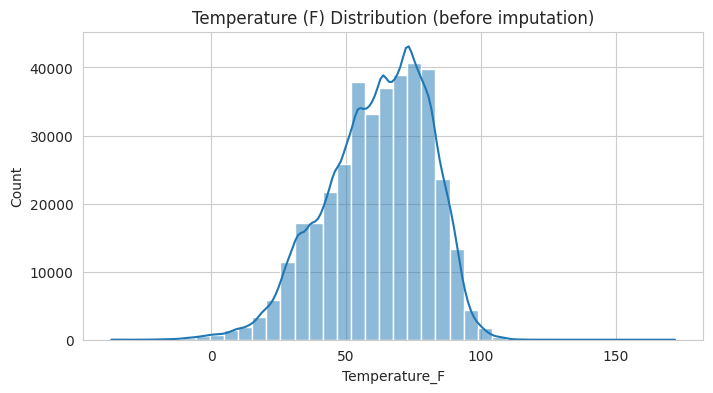

Missing values per weather column (%):
Temperature_F        2.13
Humidity_pct         2.26
Pressure_in          1.82
Visibility_mi        2.29
Wind_Speed_mph       7.39
Precipitation_in    28.58
dtype: float64


In [21]:
# Inspect a weather feature before imputation
plt.figure(figsize=(8, 4))
sns.histplot(df["Temperature_F"].dropna(), kde=True, bins=40)
plt.title("Temperature (F) Distribution (before imputation)")
plt.show()
print("Missing values per weather column (%):")
print((df[["Temperature_F", "Humidity_pct", "Pressure_in", "Visibility_mi", "Wind_Speed_mph", "Precipitation_in"]].isna().mean() * 100).round(2))

In [22]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Severity,386420.0,2.211728,1.0,2.0,2.0,2.0,4.0,0.487458
Start_Time,386420,2020-06-03 22:12:40.766963456,2016-02-08 07:59:35,2018-11-21 15:14:09.249999872,2020-11-11 01:48:48,2022-01-19 23:40:00,2023-03-31 22:59:30,NaN
End_Time,386420,2020-06-04 05:34:13.398498816,2016-02-08 08:29:35,2018-11-21 16:18:02.249999872,2020-11-11 05:46:32,2022-01-20 16:09:00.249999872,2023-03-31 23:28:00,NaN
Start_Lat,386420.0,36.213999,24.566999,33.412055,35.83507,40.092902,49.00056,5.074815
Start_Lng,386420.0,-94.695788,-124.548074,-117.221942,-87.74867,-80.350848,-67.70337,17.397779
Temperature_F,378182.0,61.662937,-37.0,49.0,64.0,76.0,172.0,19.031232
Humidity_pct,377676.0,64.850729,1.0,48.0,67.0,84.0,100.0,22.812538
Pressure_in,379394.0,29.539836,0.3,29.37,29.86,30.03,39.45,1.000317
Visibility_mi,377555.0,9.094697,0.0,10.0,10.0,10.0,100.0,2.721782
Wind_Speed_mph,357862.0,7.678508,0.0,4.6,7.0,10.4,243.0,5.30351


## Exploratory data analysis

Raw severity levels:
 Severity
1      3397
2    308076
3     64681
4     10266
Name: count, dtype: int64

Binary target (severe = Severity 3-4):
severe
0    80.6
1    19.4
Name: proportion, dtype: float64


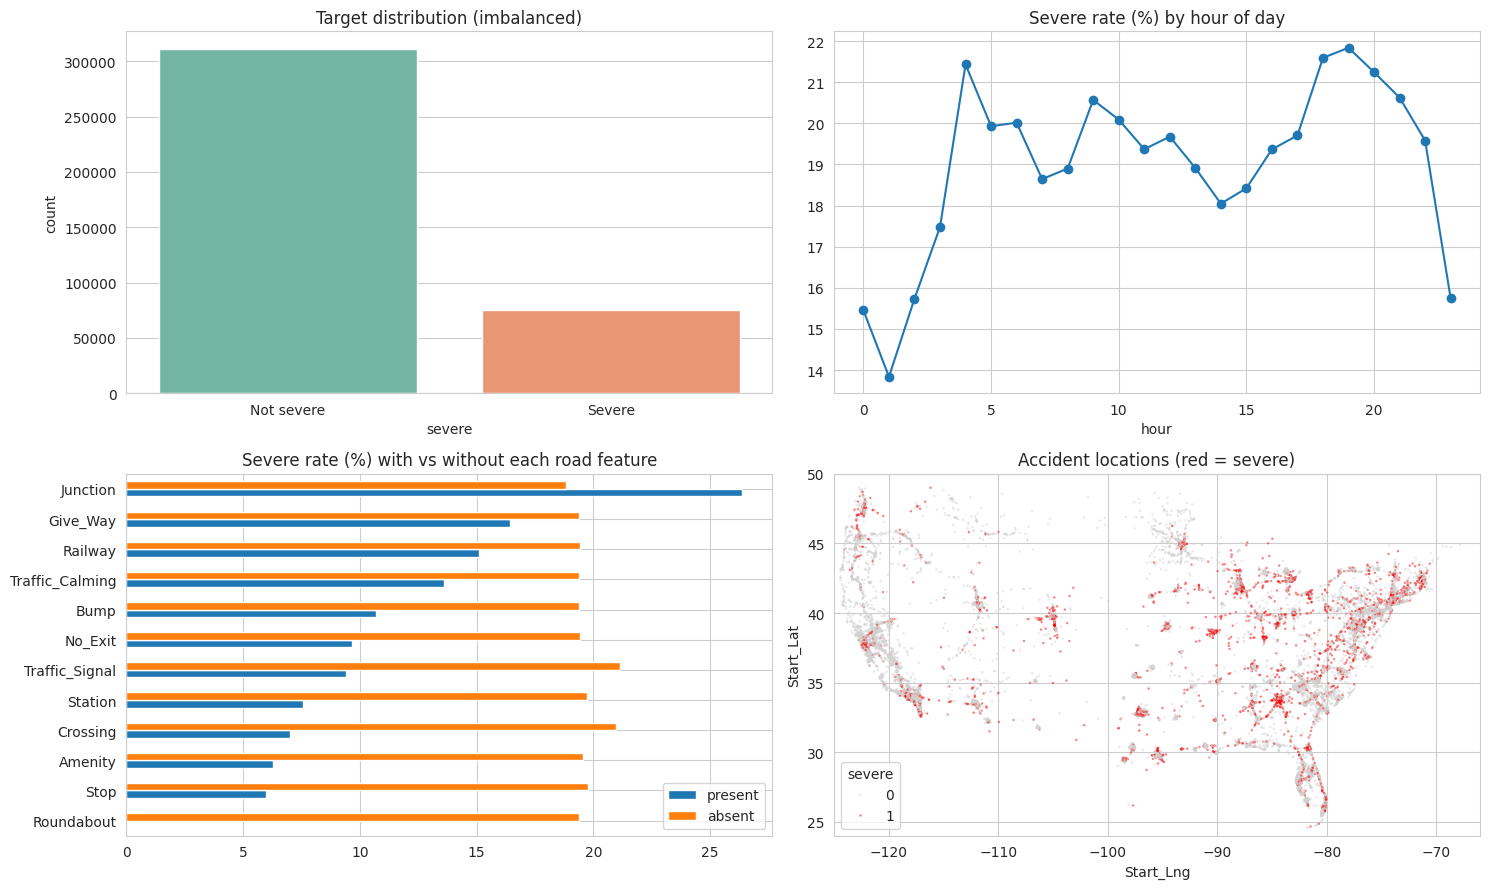

In [23]:
print("Raw severity levels:\n", severity_raw.value_counts().sort_index())
print("\nBinary target (severe = Severity 3-4):")
print((df["severe"].value_counts(normalize=True) * 100).round(2))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
sns.countplot(data=df, x="severe", palette="Set2", ax=axes[0, 0]); axes[0, 0].set_xticklabels(["Not severe", "Severe"]); axes[0, 0].set_title("Target distribution (imbalanced)")
(df.groupby("hour")["severe"].mean() * 100).plot(ax=axes[0, 1], marker="o", title="Severe rate (%) by hour of day")
road = pd.DataFrame({c: {"present": df.loc[df[c] == 1, "severe"].mean() * 100, "absent": df.loc[df[c] == 0, "severe"].mean() * 100} for c in bool_cols}).T.sort_values("present")
road.plot(kind="barh", ax=axes[1, 0], title="Severe rate (%) with vs without each road feature")
smp = df.sample(min(30000, len(df)), random_state=RANDOM_STATE)
sns.scatterplot(data=smp, x="Start_Lng", y="Start_Lat", hue="severe", palette={0: "lightgrey", 1: "red"}, s=3, alpha=0.5, linewidth=0, ax=axes[1, 1])
axes[1, 1].set_xlim(-125, -66); axes[1, 1].set_ylim(24, 50); axes[1, 1].set_title("Accident locations (red = severe)")
plt.tight_layout(); plt.show()

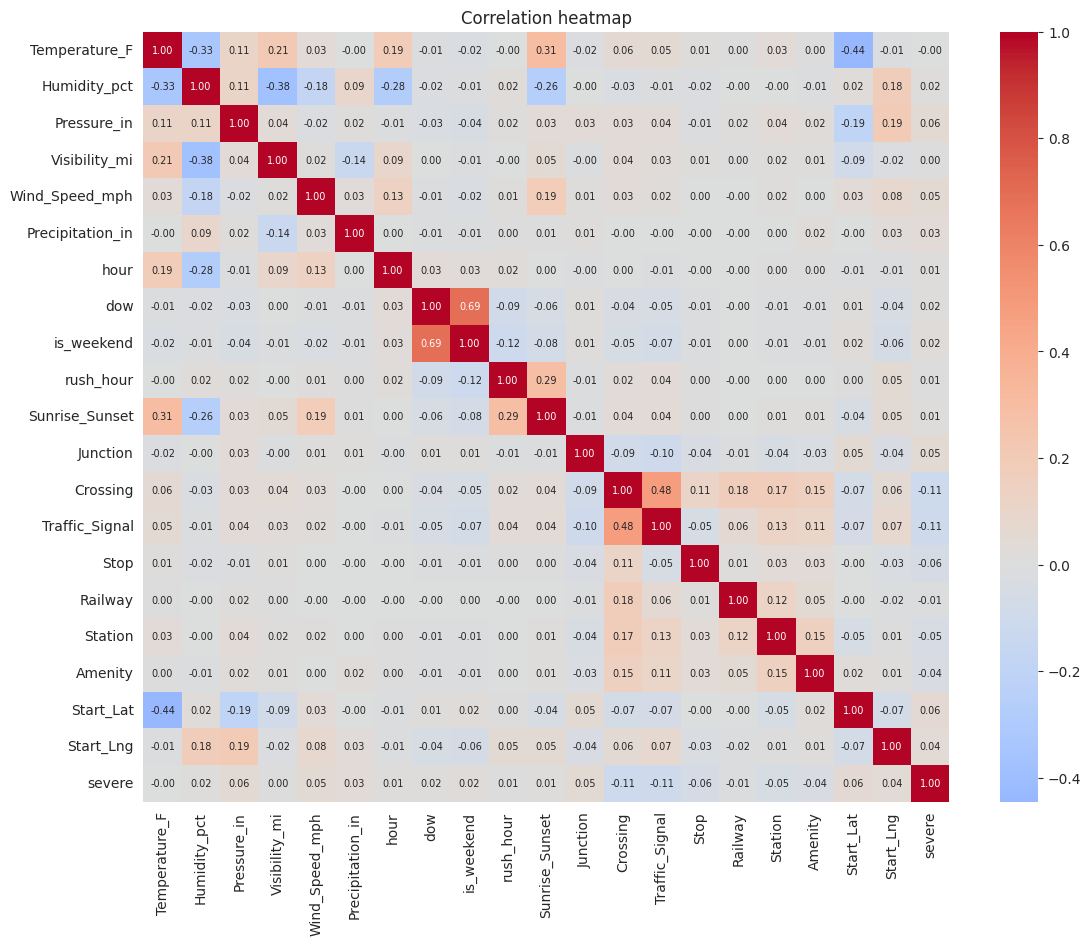

Correlation with the target:


Start_Lat           0.059
Pressure_in         0.056
Wind_Speed_mph      0.050
Junction            0.050
Start_Lng           0.041
Precipitation_in    0.031
is_weekend          0.023
Humidity_pct        0.017
dow                 0.016
hour                0.013
Sunrise_Sunset      0.010
rush_hour           0.005
Visibility_mi       0.002
Temperature_F      -0.001
Railway            -0.010
Amenity            -0.038
Station            -0.049
Stop               -0.057
Traffic_Signal     -0.105
Crossing           -0.112
Name: severe, dtype: float64

In [24]:
corr = df[weather_num + ["hour", "dow", "is_weekend", "rush_hour", "Sunrise_Sunset", "Junction", "Crossing", "Traffic_Signal",
                         "Stop", "Railway", "Station", "Amenity", "Start_Lat", "Start_Lng", "severe"]].corr()
plt.figure(figsize=(13, 10)); sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7})
plt.title("Correlation heatmap"); plt.show()
print("Correlation with the target:"); corr["severe"].drop("severe").sort_values(ascending=False).round(3)

## Train / Test split and preprocessing

In [25]:
X0 = df[BASE_FEATURES].copy()
y = df["severe"].copy()
X_train, X_test, y_train, y_test = train_test_split(X0, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

def add_density(X_fit, keys_fit, X_apply, keys_apply, is_train=False):
    counts = keys_fit.value_counts()
    c = keys_apply.map(counts).fillna(0).values - (1 if is_train else 0)
    X_apply = X_apply.copy(); X_apply["cell_density"] = np.log1p(np.clip(c, 0, None)); return X_apply, counts

X_train, cell_counts = add_density(X_train, cell_key.loc[X_train.index], X_train, cell_key.loc[X_train.index], is_train=True)
X_test, _ = add_density(X_train, cell_key.loc[X_train.index], X_test, cell_key.loc[X_test.index])
X_train, X_test = X_train[FEATURES], X_test[FEATURES]

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Severe rate  train: {:.2%} | test: {:.2%}".format(y_train.mean(), y_test.mean()))

Train: (289815, 29) | Test: (96605, 29)
Severe rate  train: 19.40% | test: 19.40%


## Model training & evaluation (classification)

In [26]:
base_clf = HistGradientBoostingClassifier(categorical_features=cat_mask, max_iter=500, early_stopping=True,
                                          n_iter_no_change=20, validation_fraction=0.1, random_state=RANDOM_STATE)
param_dist = {"learning_rate": [0.03, 0.05, 0.08, 0.1, 0.15],
              "max_leaf_nodes": [15, 31, 63, 127],
              "min_samples_leaf": [20, 50, 100, 200],
              "l2_regularization": [0.0, 0.1, 1.0, 5.0],
              "max_depth": [None, 6, 10]}

tune_idx = X_train.sample(n=min(60000, len(X_train)), random_state=RANDOM_STATE).index
search = RandomizedSearchCV(base_clf, param_dist, n_iter=N_SEARCH, scoring="roc_auc", refit=False,
                            cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE), random_state=RANDOM_STATE, n_jobs=1)
search.fit(X_train.loc[tune_idx], y_train.loc[tune_idx])
cv_res = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
print(f"Tuning done | {time.time() - T0:.0f}s elapsed")
BEST_PARAMS = search.best_params_
print("Best parameters:", BEST_PARAMS, "| CV ROC-AUC:", round(search.best_score_, 4))
cv_res[["rank_test_score", "mean_test_score", "std_test_score"] + [f"param_{k}" for k in param_dist]].head(5).round(4)

Tuning done | 177s elapsed
Best parameters: {'min_samples_leaf': 100, 'max_leaf_nodes': 63, 'max_depth': None, 'learning_rate': 0.08, 'l2_regularization': 0.0} | CV ROC-AUC: 0.7924


,rank_test_score,mean_test_score,std_test_score,param_learning_rate,param_max_leaf_nodes,param_min_samples_leaf,param_l2_regularization,param_max_depth
4,1,0.7924,0.0024,0.08,63,100,0.0,None
0,2,0.7923,0.0040,0.08,31,100,0.0,None
2,3,0.7922,0.0035,0.08,127,20,5.0,10
5,4,0.7911,0.0036,0.05,31,200,0.0,6
6,5,0.7904,0.0051,0.15,127,20,1.0,6


In [27]:
clf = HistGradientBoostingClassifier(categorical_features=cat_mask, max_iter=500, early_stopping=True,
                                     n_iter_no_change=20, validation_fraction=0.1, random_state=RANDOM_STATE, **BEST_PARAMS)
clf.fit(X_train, y_train)
print("Trees used after early stopping:", clf.n_iter_, f"| {time.time() - T0:.0f}s elapsed")

Trees used after early stopping: 500 | 200s elapsed


Out-of-fold results on the TRAINING set (no test data used):


,strategy,threshold,Accuracy,Precision,Recall,F1
0,default 0.50,0.50,0.837,0.659,0.332,0.441
1,f1,0.26,0.793,0.474,0.645,0.547
2,accuracy,0.50,0.837,0.659,0.332,0.441
3,recall,0.22,0.766,0.437,0.710,0.541


Chosen strategy: f1 -> threshold = 0.26


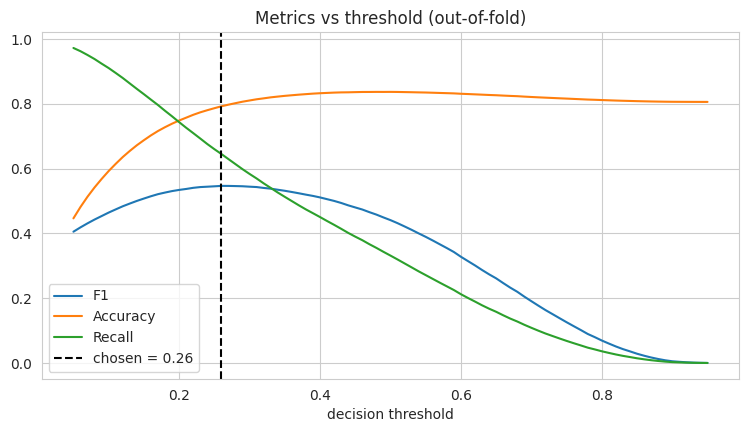

In [28]:
# Decision threshold tuning
oof = cross_val_predict(HistGradientBoostingClassifier(categorical_features=cat_mask, max_iter=clf.n_iter_, early_stopping=False,
                                                       random_state=RANDOM_STATE, **BEST_PARAMS),
                        X_train, y_train, cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE), method="predict_proba")[:, 1]

grid_t = np.linspace(0.05, 0.95, 91)
f1_g = np.array([f1_score(y_train, oof >= t) for t in grid_t])
acc_g = np.array([accuracy_score(y_train, oof >= t) for t in grid_t])
rec_g = np.array([recall_score(y_train, oof >= t) for t in grid_t])
thr_f1 = float(grid_t[f1_g.argmax()])
thr_acc = float(grid_t[acc_g.argmax()])
ok = np.where(rec_g >= TARGET_RECALL)[0]
thr_rec = float(grid_t[ok[-1]]) if len(ok) else float(grid_t[0])

thr_table = pd.DataFrame([{"strategy": n, "threshold": t, **{k: v for k, v in metrics_at(y_train, oof, t).items() if k in ["Accuracy", "Precision", "Recall", "F1"]}}
                          for n, t in [("default 0.50", 0.5), ("f1", thr_f1), ("accuracy", thr_acc), ("recall", thr_rec)]])
THRESHOLD = {"f1": thr_f1, "accuracy": thr_acc, "recall": thr_rec}[THRESHOLD_STRATEGY]
print("Out-of-fold results on the TRAINING set (no test data used):")
display(thr_table.round(3))
print(f"Chosen strategy: {THRESHOLD_STRATEGY} -> threshold = {THRESHOLD:.2f}")

plt.figure(figsize=(9, 4.5))
plt.plot(grid_t, f1_g, label="F1"); plt.plot(grid_t, acc_g, label="Accuracy"); plt.plot(grid_t, rec_g, label="Recall")
plt.axvline(THRESHOLD, ls="--", c="k", label=f"chosen = {THRESHOLD:.2f}"); plt.xlabel("decision threshold"); plt.legend(); plt.title("Metrics vs threshold (out-of-fold)"); plt.show()

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Baseline (always 'not severe'),0.806,0.000,0.000,0.000,0.500,0.194
HistGB @ 0.50,0.838,0.667,0.333,0.444,0.833,0.566
HistGB @ f1 threshold (0.26),0.794,0.478,0.653,0.552,0.833,0.566
HistGB @ accuracy threshold (0.50),0.838,0.667,0.333,0.444,0.833,0.566


              precision    recall  f1-score   support

  Not severe       0.91      0.83      0.87     77868
      Severe       0.48      0.65      0.55     18737

    accuracy                           0.79     96605
   macro avg       0.69      0.74      0.71     96605
weighted avg       0.82      0.79      0.81     96605



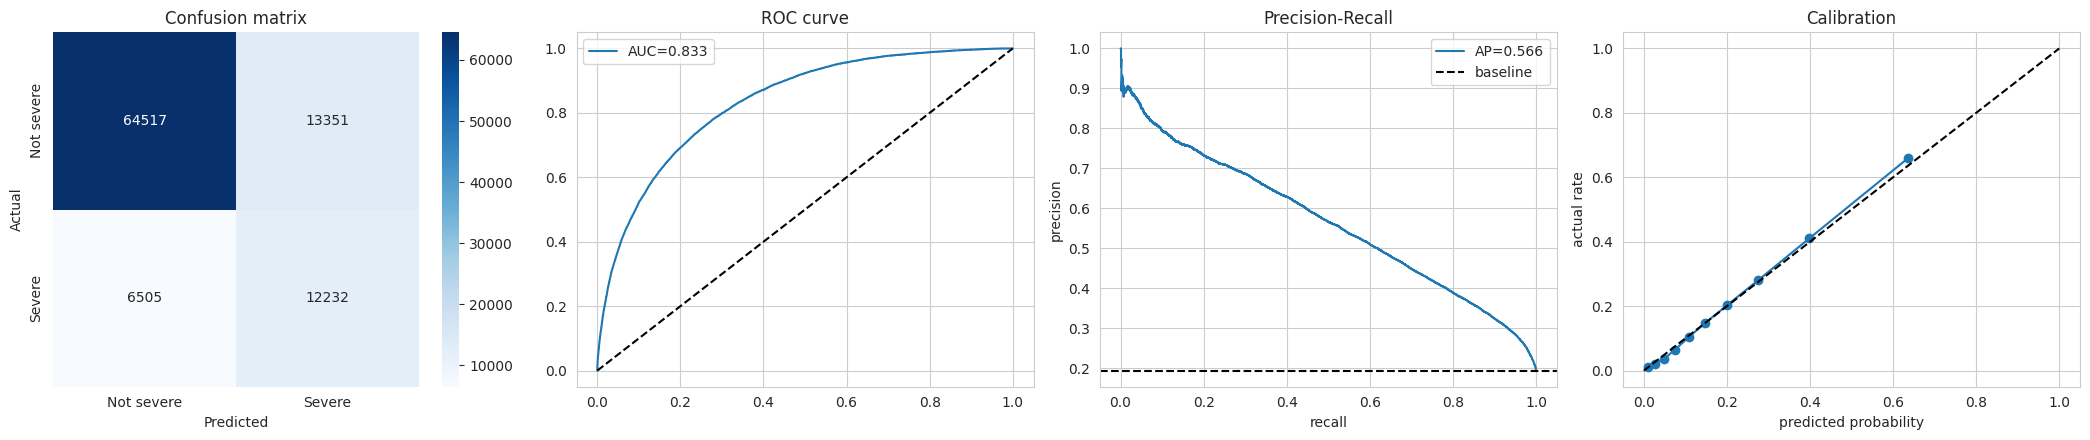

In [29]:
# Model evaluation 
proba_test = clf.predict_proba(X_test)[:, 1]
rows = {"Baseline (always 'not severe')": base_metrics,
        "HistGB @ 0.50": metrics_at(y_test, proba_test, 0.5),
        f"HistGB @ {THRESHOLD_STRATEGY} threshold ({THRESHOLD:.2f})": metrics_at(y_test, proba_test, THRESHOLD),
        f"HistGB @ accuracy threshold ({thr_acc:.2f})": metrics_at(y_test, proba_test, thr_acc)}
test_table = pd.DataFrame(rows).T
display(test_table.style.background_gradient(cmap="Greens").format("{:.3f}"))

pred_test = (proba_test >= THRESHOLD).astype(int)
print(classification_report(y_test, pred_test, target_names=["Not severe", "Severe"], zero_division=0))

fig, axes = plt.subplots(1, 4, figsize=(21, 4.5))
sns.heatmap(confusion_matrix(y_test, pred_test), annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Not severe", "Severe"], yticklabels=["Not severe", "Severe"]); axes[0].set_title("Confusion matrix"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
fpr, tpr, _ = roc_curve(y_test, proba_test); axes[1].plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, proba_test):.3f}"); axes[1].plot([0, 1], [0, 1], "k--"); axes[1].set_title("ROC curve"); axes[1].legend()
pr, rc, _ = precision_recall_curve(y_test, proba_test); axes[2].plot(rc, pr, label=f"AP={average_precision_score(y_test, proba_test):.3f}"); axes[2].axhline(y_test.mean(), c="k", ls="--", label="baseline"); axes[2].set_xlabel("recall"); axes[2].set_ylabel("precision"); axes[2].set_title("Precision-Recall"); axes[2].legend()
fp_, mp_ = calibration_curve(y_test, proba_test, n_bins=10, strategy="quantile"); axes[3].plot(mp_, fp_, "o-"); axes[3].plot([0, 1], [0, 1], "k--"); axes[3].set_title("Calibration"); axes[3].set_xlabel("predicted probability"); axes[3].set_ylabel("actual rate")
plt.tight_layout(); plt.show()

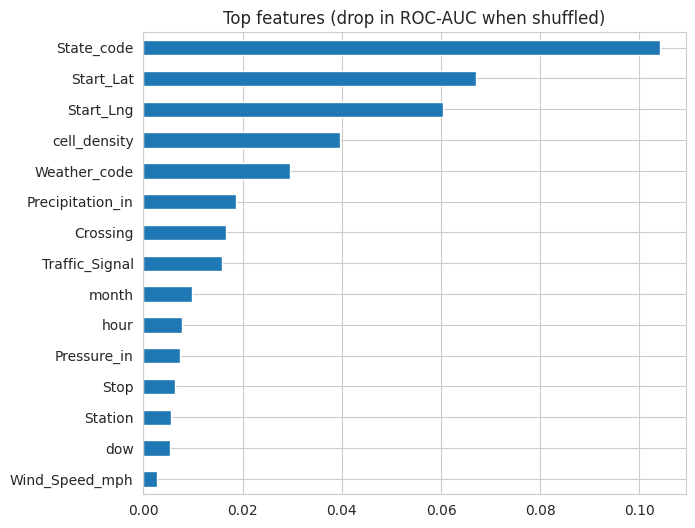

In [30]:
# Feature importance (permutation, on a 30k test sample, scored by ROC-AUC)
ps = X_test.sample(min(30000, len(X_test)), random_state=RANDOM_STATE)
imp = permutation_importance(clf, ps, y_test.loc[ps.index], scoring="roc_auc", n_repeats=3, random_state=RANDOM_STATE, n_jobs=1)
imp_s = pd.Series(imp.importances_mean, index=FEATURES).sort_values()
imp_s.tail(15).plot(kind="barh", figsize=(7, 6), title="Top features (drop in ROC-AUC when shuffled)"); plt.show()

In [31]:
# Robustness
order = np.argsort(start_time.values); cut = int(0.75 * len(X0))
tr_i, te_i = X0.index[order[:cut]], X0.index[order[cut:]]
Xt_tr, cc_t = add_density(X0.loc[tr_i], cell_key.loc[tr_i], X0.loc[tr_i], cell_key.loc[tr_i], is_train=True)
Xt_te, _ = add_density(Xt_tr, cell_key.loc[tr_i], X0.loc[te_i], cell_key.loc[te_i])
clf_t = HistGradientBoostingClassifier(categorical_features=cat_mask, max_iter=500, early_stopping=True, n_iter_no_change=20,
                                       validation_fraction=0.1, random_state=RANDOM_STATE, **BEST_PARAMS).fit(Xt_tr[FEATURES], y.loc[tr_i])
pt = clf_t.predict_proba(Xt_te[FEATURES])[:, 1]
cmp = pd.DataFrame({"Random split": metrics_at(y_test, proba_test, THRESHOLD),
                    "Chronological split": metrics_at(y.loc[te_i], pt, THRESHOLD)}).T
print("Chronological test period starts:", start_time.loc[te_i].min().date())
display(cmp.round(3))

Chronological test period starts: 2022-01-19


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Random split,0.794,0.478,0.653,0.552,0.833,0.566
Chronological split,0.732,0.128,0.575,0.210,0.733,0.143


## impact-duration regression (how long the accident affects traffic)

In [32]:
dtr, dte = duration.loc[X_train.index], duration.loc[X_test.index]
mtr, mte = dtr.notna().values, dte.notna().values
reg = HistGradientBoostingRegressor(categorical_features=cat_mask, max_iter=400, learning_rate=0.08, max_leaf_nodes=31,
                                    min_samples_leaf=50, early_stopping=True, n_iter_no_change=20, random_state=RANDOM_STATE)
reg.fit(X_train[mtr], np.log1p(dtr[mtr]))                       # log scale: durations are right-skewed
pred_min = np.clip(np.expm1(reg.predict(X_test[mte])), 0, None); true_min = dte[mte].values
print(f"Baseline (median) MAE: {mean_absolute_error(true_min, np.full(len(true_min), dtr[mtr].median())):.1f} min")
print(f"HistGB regressor MAE : {mean_absolute_error(true_min, pred_min):.1f} min")
print(f"R2 (log scale)       : {r2_score(np.log1p(true_min), np.log1p(pred_min)):.3f}")

Baseline (median) MAE: 68.4 min
HistGB regressor MAE : 61.6 min
R2 (log scale)       : 0.171


## hotspot zones (K-Means on accident locations)

,zone,centre_lat,centre_lng,n_train,severe_rate_pct,severe_rate_test_pct,top_state
1,1,33.88,-117.10,44269,18.34,18.32,CA
2,2,27.37,-81.23,31005,13.78,13.62,FL
10,10,34.88,-80.68,29598,12.53,12.86,SC
11,11,39.40,-77.05,29351,19.95,20.57,VA
6,6,31.58,-95.88,29309,18.69,19.58,TX
5,5,37.95,-121.57,28152,12.71,12.32,CA
0,0,41.28,-73.55,23432,24.27,23.36,NY
9,9,41.39,-85.56,21480,33.03,32.95,IL
4,4,33.67,-86.36,19054,27.43,26.80,TN
3,3,42.79,-93.54,13405,23.14,22.76,MN


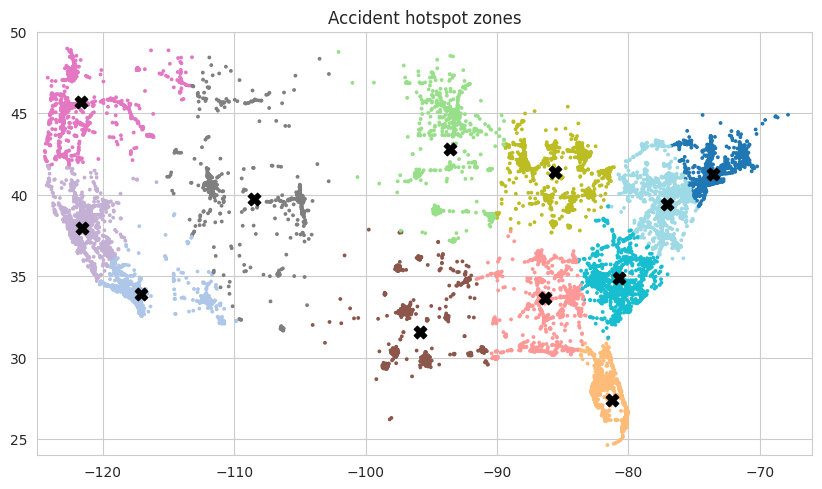

In [34]:
K_LOC = 12
coords = X_train[["Start_Lat", "Start_Lng"]].values
km = KMeans(n_clusters=K_LOC, random_state=RANDOM_STATE, n_init=10).fit(coords)
zone_tr, zone_te = km.labels_, km.predict(X_test[["Start_Lat", "Start_Lng"]].values)
zones = pd.DataFrame({
    "zone": range(K_LOC), "centre_lat": km.cluster_centers_[:, 0].round(3), "centre_lng": km.cluster_centers_[:, 1].round(3),
    "n_train": np.bincount(zone_tr, minlength=K_LOC),
    "severe_rate_pct": [y_train.values[zone_tr == z].mean() * 100 for z in range(K_LOC)],
    "severe_rate_test_pct": [y_test.values[zone_te == z].mean() * 100 if (zone_te == z).any() else np.nan for z in range(K_LOC)],
    "top_state": [state.loc[X_train.index[zone_tr == z]].mode().iloc[0] for z in range(K_LOC)]}).round(2)
display(zones.sort_values("n_train", ascending=False))

sm = np.random.RandomState(RANDOM_STATE).choice(len(coords), size=min(30000, len(coords)), replace=False)
plt.figure(figsize=(10, 5.5)); plt.scatter(coords[sm, 1], coords[sm, 0], c=zone_tr[sm], cmap="tab20", s=3)
plt.scatter(km.cluster_centers_[:, 1], km.cluster_centers_[:, 0], c="black", marker="X", s=80)
plt.xlim(-125, -66); plt.ylim(24, 50); plt.title("Accident hotspot zones"); plt.show()

## App

In [35]:
os.makedirs("artifacts", exist_ok=True)
fi = imp_s.sort_values(ascending=False).head(15)
config = {
    "features": FEATURES, "cat_cols": CAT_COLS, "bool_cols": bool_cols, "rush_hours": RUSH_HOURS, "grid": GRID,
    "state_codes": state_codes, "weather_codes": weather_codes,
    "threshold": float(THRESHOLD), "threshold_strategy": THRESHOLD_STRATEGY,
    "best_params": {k: (None if v is None else (float(v) if isinstance(v, (float, np.floating)) else int(v))) for k, v in BEST_PARAMS.items()},
    "test_metrics": {k: {m: float(v) for m, v in d.items()} for k, d in test_table.T.to_dict().items()} if False else
                    {k: {m: float(v) for m, v in d.items()} for k, d in test_table.to_dict("index").items()},
    "feature_importance": {k: float(v) for k, v in fi.items()},
    "sample_frac": SAMPLE_FRAC, "n_train": int(len(X_train)), "sklearn_version": sklearn.__version__}
json.dump(config, open("artifacts/config.json", "w"), indent=2)
joblib.dump(clf, "artifacts/severity_model.joblib")
joblib.dump(reg, "artifacts/duration_model.joblib")
joblib.dump({k: int(v) for k, v in cell_counts.items()}, "artifacts/cell_counts.joblib")
zones[["zone", "centre_lat", "centre_lng", "n_train", "severe_rate_pct", "top_state"]].to_csv("artifacts/zones.csv", index=False)
open("requirements.txt", "w").write("\n".join(["streamlit", f"scikit-learn=={sklearn.__version__}", f"pandas=={pd.__version__}",
                                                 f"numpy=={np.__version__}", f"joblib=={joblib.__version__}"]) + "\n")

# ---------------------------------------------------------------- predictor.py
predictor_code = r'''# predictor.py - loads the trained artifacts and turns raw inputs into predictions.
# Used by both the notebook and the Streamlit app (no Streamlit dependency here).
import os
import json
import numpy as np
import pandas as pd
import joblib

ART_DIR = os.environ.get("ARTIFACT_DIR", "artifacts")


class AccidentPredictor:
    def __init__(self, art_dir=None):
        art_dir = art_dir or ART_DIR
        with open(os.path.join(art_dir, "config.json")) as f:
            self.cfg = json.load(f)
        self.clf = joblib.load(os.path.join(art_dir, "severity_model.joblib"))
        self.reg = joblib.load(os.path.join(art_dir, "duration_model.joblib"))
        self.cell_counts = joblib.load(os.path.join(art_dir, "cell_counts.joblib"))
        self.zones = pd.read_csv(os.path.join(art_dir, "zones.csv"))
        self.features = self.cfg["features"]
        self.threshold = float(self.cfg["threshold"])

    def _row(self, r):
        cfg = self.cfg
        t = pd.Timestamp(r["when"])
        hour = int(t.hour)
        sun = r.get("sunrise_sunset", "Auto")
        if sun == "Auto":
            sun_val = 1 if 6 <= hour < 19 else 0
        else:
            sun_val = 1 if sun == "Day" else 0

        grid = cfg["grid"]
        key = str(int(np.floor(r["lat"] / grid))) + "_" + str(int(np.floor(r["lng"] / grid)))
        density = float(np.log1p(self.cell_counts.get(key, 0)))

        weather_codes = cfg["weather_codes"]
        wcode = weather_codes.get(r.get("weather_condition", "Unknown"), weather_codes["Other"])
        scode = cfg["state_codes"].get(r.get("state"), np.nan)

        def val(name):
            v = r.get(name)
            return np.nan if v is None else float(v)

        row = {
            "Start_Lat": float(r["lat"]), "Start_Lng": float(r["lng"]),
            "State_code": scode, "Weather_code": wcode,
            "Temperature_F": val("temperature_f"), "Humidity_pct": val("humidity_pct"),
            "Pressure_in": val("pressure_in"), "Visibility_mi": val("visibility_mi"),
            "Wind_Speed_mph": val("wind_speed_mph"), "Precipitation_in": val("precipitation_in"),
            "Sunrise_Sunset": sun_val,
            "hour": hour, "dow": int(t.dayofweek), "month": int(t.month),
            "is_weekend": int(t.dayofweek >= 5), "rush_hour": int(hour in cfg["rush_hours"]),
            "cell_density": density,
        }
        present = set(r.get("road_features", ()))
        for c in cfg["bool_cols"]:
            row[c] = 1 if c in present else 0
        return row

    def predict_many(self, records):
        rows = pd.DataFrame([self._row(r) for r in records])[self.features].astype(float)
        proba = self.clf.predict_proba(rows)[:, 1]
        dur = np.expm1(self.reg.predict(rows))
        out = pd.DataFrame({
            "probability": proba,
            "high_risk": proba >= self.threshold,
            "duration_min": np.clip(dur, 0, None),
        })
        out["hour"] = rows["hour"].astype(int).values
        return out

    def nearest_zone(self, lat, lng):
        z = self.zones
        dlat = (z["centre_lat"] - lat) * 111.0
        dlng = (z["centre_lng"] - lng) * 111.0 * np.cos(np.radians(lat))
        dist = np.sqrt(dlat ** 2 + dlng ** 2)
        i = int(np.argmin(dist.values))
        zone = z.iloc[i].to_dict()
        zone["distance_km"] = float(dist.iloc[i])
        return zone

    def predict(self, lat, lng, when, state=None, **kwargs):
        rec = dict(lat=lat, lng=lng, when=when, state=state, **kwargs)
        res = self.predict_many([rec]).iloc[0]
        return {
            "probability": float(res["probability"]),
            "high_risk": bool(res["high_risk"]),
            "threshold": self.threshold,
            "duration_min": float(res["duration_min"]),
            "zone": self.nearest_zone(lat, lng),
        }
'''

# ---------------------------------------------------------------- app.py (Streamlit)
app_code = r'''# app.py - Streamlit app to test the accident severity model.
# Run:  streamlit run app.py   (needs the 'artifacts' folder and predictor.py next to it)
import datetime as dt
import pandas as pd
import streamlit as st
from predictor import AccidentPredictor

CITIES = {
    "Los Angeles, CA": ("CA", 34.05, -118.24),
    "New York, NY": ("NY", 40.71, -74.01),
    "Houston, TX": ("TX", 29.76, -95.37),
    "Chicago, IL": ("IL", 41.88, -87.63),
    "Miami, FL": ("FL", 25.76, -80.19),
    "Atlanta, GA": ("GA", 33.75, -84.39),
    "Seattle, WA": ("WA", 47.61, -122.33),
    "Phoenix, AZ": ("AZ", 33.45, -112.07),
    "Custom location": (None, 39.50, -98.35),
}

st.set_page_config(page_title="Accident Severity Predictor", page_icon="🚨", layout="wide")


@st.cache_resource
def load_predictor():
    return AccidentPredictor()


def main():
    P = load_predictor()
    cfg = P.cfg

    st.title("🚨 US Accident Severity & Impact Predictor")
    st.caption("Enter the conditions of an accident. The model estimates how likely it is to be severe "
               "(Severity 3-4) and how long it will affect traffic. Trained on the US Accidents dataset.")

    tab_predict, tab_zones, tab_info = st.tabs(["Predict", "Hotspot zones", "Model info"])

    with tab_predict:
        left, right = st.columns([1, 1])

        with left:
            st.subheader("Where and when")
            city = st.selectbox("Location preset", list(CITIES))
            state0, lat0, lng0 = CITIES[city]
            states = sorted(cfg["state_codes"])
            state = st.selectbox("State", states, index=states.index(state0) if state0 in states else 0,
                                 key="state_" + city)
            lat = st.number_input("Latitude", value=float(lat0), format="%.4f", key="lat_" + city)
            lng = st.number_input("Longitude", value=float(lng0), format="%.4f", key="lng_" + city)
            date = st.date_input("Date", value=dt.date(2022, 11, 18))
            time = st.time_input("Time", value=dt.time(17, 30))

            st.subheader("Weather")
            temp = st.slider("Temperature (F)", -20, 120, 60)
            humidity = st.slider("Humidity (%)", 0, 100, 60)
            pressure = st.slider("Pressure (in)", 24.0, 32.0, 29.9)
            visibility = st.slider("Visibility (miles)", 0.0, 10.0, 10.0)
            wind = st.slider("Wind speed (mph)", 0, 60, 8)
            precip = st.slider("Precipitation (in)", 0.0, 2.0, 0.0)
            conds = list(cfg["weather_codes"])
            cond = st.selectbox("Weather condition", conds, index=conds.index("Clear") if "Clear" in conds else 0)

            st.subheader("Road features nearby")
            roads = st.multiselect("Select all that apply", cfg["bool_cols"], default=[])

        when = dt.datetime.combine(date, time)
        inputs = dict(lat=lat, lng=lng, state=state, when=when, temperature_f=temp, humidity_pct=humidity,
                      pressure_in=pressure, visibility_mi=visibility, wind_speed_mph=wind,
                      precipitation_in=precip, weather_condition=cond, road_features=roads)
        res = P.predict(**inputs)

        with right:
            st.subheader("Prediction")
            p = res["probability"]
            c1, c2 = st.columns(2)
            c1.metric("Probability of severe accident", f"{p:.1%}")
            c2.metric("Estimated impact duration", f"{res['duration_min']:.0f} min")
            st.progress(float(min(max(p, 0.0), 1.0)))
            if res["high_risk"]:
                st.error(f"HIGH RISK: probability is above the decision threshold ({res['threshold']:.2f}).")
            else:
                st.success(f"Lower risk: probability is below the decision threshold ({res['threshold']:.2f}).")
            st.caption("Impact duration is how long the accident affects traffic (a proxy for clearance time), "
                       "not emergency response time.")

            zone = res["zone"]
            st.markdown("**Nearest hotspot zone:** zone " + str(int(zone["zone"])) + " (mostly " + str(zone["top_state"])
                        + "), " + format(zone["distance_km"], ".0f") + " km from its centre. "
                        + "Historical severe rate in this zone: " + format(zone["severe_rate_pct"], ".1f") + "%.")
            st.map(pd.DataFrame({"lat": [lat], "lon": [lng]}))

            st.markdown("**Risk by hour of day** (same place, date and conditions)")
            sweep = P.predict_many([dict(inputs, when=dt.datetime.combine(date, dt.time(h, 0))) for h in range(24)])
            st.line_chart(sweep.set_index("hour")["probability"])

    with tab_zones:
        st.subheader("Accident hotspot zones (K-Means on accident locations)")
        st.dataframe(P.zones, use_container_width=True)
        st.map(P.zones.rename(columns={"centre_lat": "lat", "centre_lng": "lon"})[["lat", "lon"]])

    with tab_info:
        st.subheader("Model")
        st.write("Algorithm: Histogram Gradient Boosting (scikit-learn), tuned with randomized search and "
                 "cross-validation; decision threshold chosen on out-of-fold predictions "
                 "(strategy: " + str(cfg["threshold_strategy"]) + ").")
        st.write("Test-set performance (data never used for training or tuning):")
        st.dataframe(pd.DataFrame(cfg["test_metrics"]).T.round(3), use_container_width=True)
        st.write("Most important features:")
        st.bar_chart(pd.Series(cfg["feature_importance"]).sort_values())
        st.warning("Severity in this dataset describes traffic impact, not injuries. The model supports risk "
                   "awareness and planning; it is not a substitute for emergency-service judgement.")


if __name__ == "__main__":
    main()
'''

open("predictor.py", "w").write(predictor_code)
open("app.py", "w").write(app_code)
print("Saved:", sorted(os.listdir("artifacts")), "+ predictor.py, app.py, requirements.txt in", os.getcwd())

Saved: ['cell_counts.joblib', 'config.json', 'duration_model.joblib', 'severity_model.joblib', 'zones.csv'] + predictor.py, app.py, requirements.txt in /kaggle/working


In [ ]:
RUN_STREAMLIT = True     

if RUN_STREAMLIT:
    import subprocess, re, urllib.request, stat
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "streamlit"], check=True)
    if not os.path.exists("cloudflared"):
        urllib.request.urlretrieve("https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64", "cloudflared")
        os.chmod("cloudflared", os.stat("cloudflared").st_mode | stat.S_IEXEC)
    app_proc = subprocess.Popen([sys.executable, "-m", "streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true",
                                 "--browser.gatherUsageStats", "false"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    time.sleep(8)
    tunnel = subprocess.Popen(["./cloudflared", "tunnel", "--url", "http://localhost:8501", "--no-autoupdate"],
                              stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    url, t_end = None, time.time() + 90
    for line in tunnel.stdout:
        m = re.search(r"https://[a-z0-9-]+\.trycloudflare\.com", line)
        if m: url = m.group(0); break
        if time.time() > t_end: break
    print("Open your app here ->", url or "no URL found; check that Internet is ON in Session options")
    print("Keep this cell running while you test. Interrupt the kernel to stop.")
    tunnel.wait()
else:
    print("Skipped. Enable Internet in Session options, set RUN_STREAMLIT = True, and re-run this cell.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 50.6 MB/s eta 0:00:00
Open your app here -> https://responding-small-properties-nodes.trycloudflare.com
Keep this cell running while you test. Interrupt the kernel to stop.
